In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
df=pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [72]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [73]:
cols=[]
for var in df.columns:
    if df[var].isnull().mean() * 100 <= 5:
        cols.append(var)
cols

['enrollee_id',
 'city',
 'city_development_index',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours',
 'target']

In [74]:
df.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [75]:
new_df = df[cols].dropna()
new_df

,enrollee_id,city,city_development_index,relevent_experience,enrolled_university,education_level,experience,training_hours,target
0,8949,city_103,0.920,Has relevent experience,no_enrollment,Graduate,20.0,36.0,1.0
1,29725,city_40,0.776,No relevent experience,no_enrollment,Graduate,15.0,47.0,0.0
2,11561,city_21,0.624,No relevent experience,Full time course,Graduate,5.0,83.0,0.0
4,666,city_162,0.767,Has relevent experience,no_enrollment,Masters,20.0,8.0,0.0
5,21651,city_176,0.764,Has relevent experience,Part time course,Graduate,11.0,24.0,1.0
...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,No relevent experience,no_enrollment,Graduate,14.0,42.0,1.0
19154,31398,city_103,0.920,Has relevent experience,no_enrollment,Graduate,14.0,52.0,1.0
19155,24576,city_103,0.920,Has relevent experience,no_enrollment,Graduate,20.0,44.0,0.0
19156,5756,city_65,0.802,Has relevent experience,no_enrollment,High School,0.0,97.0,0.0


In [85]:
def graphs(wow):
    plt.figure(figsize=(14, 5))
    
    plt.hist(df[wow], color='green', bins=50, alpha=0.5, label='Before')
    plt.hist(new_df[wow], color='red', bins=50, alpha=0.5, label='After')
    
    plt.title(wow)
    plt.legend()
    plt.show()

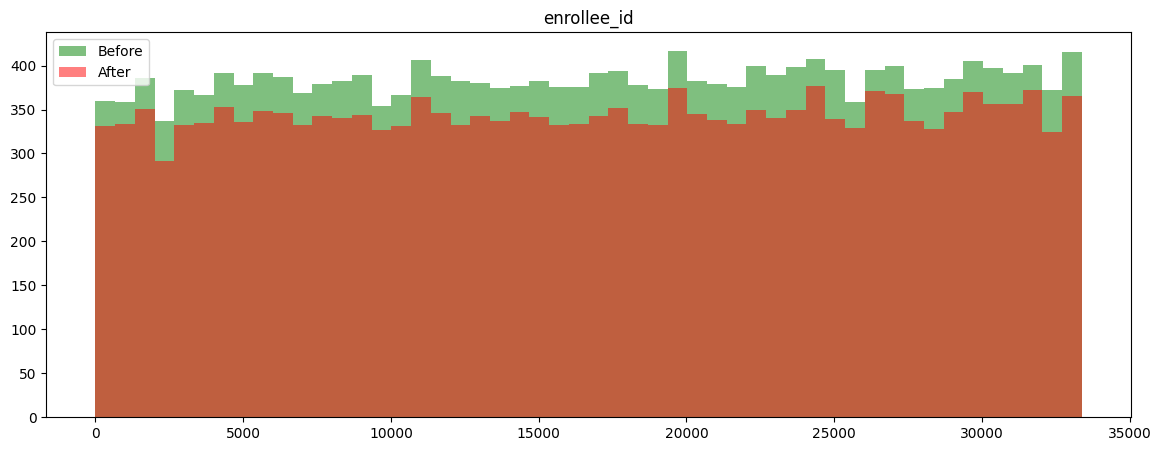

In [86]:
graphs("enrollee_id")

## for categorical columns

In [80]:
cat = pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    
    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1)

cat.columns=['original','cca']
cat

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079
